In [2]:
import pandas as pd
col_names = ["duration", "protocol_type", "service", "flag", "src_bytes", 
             "dst_bytes", "land", "wrong_fragment", "urgent", "hot", 
             "num_failed_logins", "logged_in", "num_compromised", "root_shell", 
             "su_attempted", "num_root", "num_file_creations", "num_shells", 
             "num_access_files", "num_outbound_cmds", "is_host_login", 
             "is_guest_login", "count", "srv_count", "serror_rate", 
             "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate", 
             "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", 
             "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate", 
             "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", 
             "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate", 
             "dst_host_srv_rerror_rate", "label", "difficulty_level"]


df = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\KDDTrain+.txt", names=col_names, header=None)
print("Datanın Ölçüsü (Sətir, Sütun):", df.shape)
df.head()

Datanın Ölçüsü (Sətir, Sütun): (125973, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [3]:

print("--- Sütunlar üzrə boş xanaların sayı ---")
null_counts = df.isnull().sum()
if null_counts.sum() > 0:
    df.dropna(inplace=True)
    print("Boş xanalar uğurla təmizləndi. Yeni data ölçüsü:", df.shape)
else:
    print("Heç bir sütunda boş xana yoxdur.")

print("\n--- Təkrarlanan sətirlərin analizi ---")
duplicates_count = df.duplicated().sum()
print("Tapılan təkrarlanan (dublikat) sətirlərin sayı:", duplicates_count)
if duplicates_count > 0:
    df.drop_duplicates(inplace=True)
    print("Təkrarlanan sətirlər uğurla təmizləndi. Yeni data ölçüsü:", df.shape)
else:
    print("Məlumat massivində təkrarlanan sətir aşkar edilmədi.")

--- Sütunlar üzrə boş xanaların sayı ---
Heç bir sütunda boş xana yoxdur.

--- Təkrarlanan sətirlərin analizi ---
Tapılan təkrarlanan (dublikat) sətirlərin sayı: 0
Məlumat massivində təkrarlanan sətir aşkar edilmədi.


<Figure size 800x600 with 0 Axes>

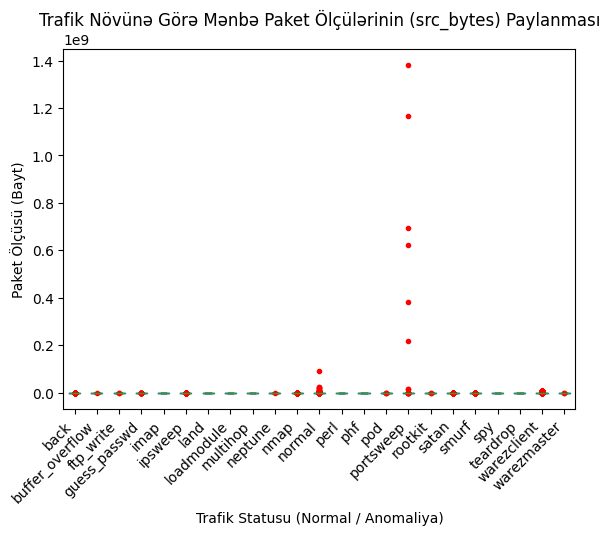

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
df.boxplot(column='src_bytes', by='label', grid=False, sym='r.')
plt.xticks(rotation=45, ha='right')
plt.title('Trafik Növünə Görə Mənbə Paket Ölçülərinin (src_bytes) Paylanması')
plt.suptitle('')
plt.xlabel('Trafik Statusu (Normal / Anomaliya)')
plt.ylabel('Paket Ölçüsü (Bayt)')
plt.show()

In [5]:

selected_features = ["duration", "src_bytes", "dst_bytes", "wrong_fragment", 
                     "hot", "num_failed_logins", "logged_in", "count", "srv_count"]

correlation_matrix = df[selected_features].corr(method='pearson')
print("--- Şəbəkə Parametrlərinin Pearson Korrelyasiya Matrisi ---")
print(correlation_matrix.round(2))

--- Şəbəkə Parametrlərinin Pearson Korrelyasiya Matrisi ---
                   duration  src_bytes  dst_bytes  wrong_fragment   hot  \
duration               1.00       0.07       0.03           -0.01  0.00   
src_bytes              0.07       1.00       0.00           -0.00  0.00   
dst_bytes              0.03       0.00       1.00           -0.00 -0.00   
wrong_fragment        -0.01      -0.00      -0.00            1.00 -0.01   
hot                    0.00       0.00      -0.00           -0.01  1.00   
num_failed_logins      0.01      -0.00       0.00           -0.00  0.00   
logged_in             -0.06      -0.00      -0.00           -0.07  0.12   
count                 -0.08      -0.01      -0.00           -0.02 -0.07   
srv_count             -0.04      -0.00      -0.00            0.02 -0.03   

                   num_failed_logins  logged_in  count  srv_count  
duration                        0.01      -0.06  -0.08      -0.04  
src_bytes                      -0.00      -0.00  -0.0

In [6]:
import statsmodels.api as sm
Y = df['count']
X = df[['srv_count', 'logged_in', 'duration', 'hot']]
X = sm.add_constant(X)
model = sm.OLS(Y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.438
Model:                            OLS   Adj. R-squared:                  0.438
Method:                 Least Squares   F-statistic:                 2.451e+04
Date:                Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:15:24   Log-Likelihood:            -7.3968e+05
No. Observations:              125973   AIC:                         1.479e+06
Df Residuals:                  125968   BIC:                         1.479e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        112.6545      0.342    329.278      0.0

In [7]:
from scipy import stats

normal_count = df[df['label'] == 'normal']['count']
attack_count = df[df['label'] != 'normal']['count']
mean_norm=normal_count.mean() 
std_norm=normal_count.std(ddof=1)
mean_att=attack_count.mean()
std_att=attack_count.std(ddof=1)

print("--- 1. Kolmoqorov-Smirnov (KS) Normallıq Testi Nəticələri ---")
ks_stat_norm, ks_p_norm = stats.kstest(normal_count, 'norm',args=(mean_norm,std_norm))
ks_stat_att, ks_p_att = stats.kstest(attack_count, 'norm', args=(mean_att,std_att))
print(f"Normal Trafik üçün  -> KS statistikası: {ks_stat_norm:.4f}, p-value: {ks_p_norm}")
if ks_p_norm>0.05:
    print("Normal trafik üçün data normal paylanıb. H0 hipotezi qəbul edilir.")
else:
    print("Normal trafik üçün data normal paylanmayıb. H0 hipotezi rədd edilir.")

print(f"Hücum Trafiki üçün  -> KS statistikası: {ks_stat_att:.4f}, p-value: {ks_p_att}")
if ks_p_att>0.05:
    print("Hücum trafiki üçün data normal paylanıb. H0 hipotezi qəbul edilir.")
else:
    print("Hücum trafiki üçün data normal paylanmayıb. H0 hipotezi rədd edilir.")
    
print("\n--- 2. Mann-Whitney U Testi Nəticələri ---")
t_stat, t_p_val = stats.mannwhitneyu(normal_count, attack_count)
print(f"t-statistikası: {t_stat:.4f}")
print(f"p-value (Statistik Ehtimallıq): {t_p_val}")
if t_p_val<0.05:
    print("Hücum trafiki və normal trafik paylanmaları arasında əhəmiyyyətli fərq var. H0 hipotezi rədd edilir.")
else:
    print("Hücum trafiki və normal trafik paylanmaları arasında əhəmiyyyətli fərq yoxdur. H0 hipotezi qəbul edilir.")

--- 1. Kolmoqorov-Smirnov (KS) Normallıq Testi Nəticələri ---
Normal Trafik üçün  -> KS statistikası: 0.3469, p-value: 0.0
Normal trafik üçün data normal paylanmayıb. H0 hipotezi rədd edilir.
Hücum Trafiki üçün  -> KS statistikası: 0.1079, p-value: 0.0
Hücum trafiki üçün data normal paylanmayıb. H0 hipotezi rədd edilir.

--- 2. Mann-Whitney U Testi Nəticələri ---
t-statistikası: 707519273.5000
p-value (Statistik Ehtimallıq): 0.0
Hücum trafiki və normal trafik paylanmaları arasında əhəmiyyyətli fərq var. H0 hipotezi rədd edilir.


In [8]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
attack_dict = {
    'neptune':'DoS', 'back':'DoS', 'land':'DoS', 'pod':'DoS', 'smurf':'DoS', 'teardrop':'DoS', 'mailbomb':'DoS', 'apache2':'DoS', 'processtable':'DoS', 'udpstorm':'DoS', 'worm':'DoS',
    'satan':'Probe', 'ipsweep':'Probe', 'portsweep':'Probe', 'nmap':'Probe', 'mscan':'Probe', 'saint':'Probe',
    'guess_passwd':'R2L', 'ftp_write':'R2L', 'imap':'R2L', 'phf':'R2L', 'multihop':'R2L', 'warezmaster':'R2L', 'warezclient':'R2L', 'spy':'R2L', 'xlock':'R2L', 'xsnoop':'R2L', 'snmpguess':'R2L', 'snmpgetattack':'R2L', 'httptunnel':'R2L', 'sendmail':'R2L', 'named':'R2L',
    'buffer_overflow':'U2R', 'loadmodule':'U2R', 'perl':'U2R', 'rootkit':'U2R', 'ps':'U2R', 'xterm':'U2R', 'sqlattack':'U2R',
    'normal':'Normal'
}

df['attack_category'] = df['label'].map(attack_dict).fillna('Digər')

print("--- Tukey HSD Post-Hoc Testi Nəticələri ---")
tukey = pairwise_tukeyhsd(endog=df['count'],
                          groups=df['attack_category'],
                          alpha=0.05)
print(tukey.summary())

--- Tukey HSD Post-Hoc Testi Nəticələri ---
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower     upper   reject
---------------------------------------------------------
   DoS Normal -155.5721    0.0 -157.0303 -154.1139   True
   DoS  Probe -101.0378    0.0 -103.5369  -98.5387   True
   DoS    R2L -176.7925    0.0 -184.5137 -169.0714   True
   DoS    U2R -172.2823    0.0 -205.7162 -138.8485   True
Normal  Probe   54.5343    0.0    52.117   56.9516   True
Normal    R2L  -21.2205    0.0  -28.9156  -13.5253   True
Normal    U2R  -16.7103 0.6511   -50.138   16.7175  False
 Probe    R2L  -75.7548    0.0   -83.713  -67.7965   True
 Probe    U2R  -71.2446    0.0 -104.7339  -37.7552   True
   R2L    U2R    4.5102 0.9965  -29.7667   38.7871  False
---------------------------------------------------------


In [10]:

df.to_csv(r'C:\Users\ASUS\OneDrive\Desktop\nsl_kdd_temiz_data.csv', index=False)
print("Data uğurla 'nsl_kdd_temiz_data.csv' adı ilə yadda saxlanıldı!")

Data uğurla 'nsl_kdd_temiz_data.csv' adı ilə yadda saxlanıldı!
